# Solution

### OK now we have a valid method we will try to improve it

we will map the knapstack in a different way, with just one list of size NUM_ITEMS
each position will contain the knapstack number where the item is placed, or -1 if not placed

we will introduce a new parameter, the "emptiness ratio", that is the percentage of knapstack left empty, this helps us decide if we want to add a new item or remove an existing one or move an item from one knapstack to another

In [1]:
import numpy as np

In [2]:
# Problem 1:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 3
NUM_ITEMS = 20
NUM_DIMENSIONS = 2
VALUES = rng.integers(0, 100, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 100, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    0, 100 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

print("VALUES =", VALUES)

VALUES = [ 8 77 65 43 43 85  8 69 20  9 52 97 73 76 71 78 51 12 83 45]


In [34]:
# Problem 2:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 10
NUM_ITEMS = 100
NUM_DIMENSIONS = 10
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 2, 1000 * NUM_ITEMS // NUM_KNAPSACKS, size=(NUM_KNAPSACKS, NUM_DIMENSIONS)
)

In [4]:
# Problem 3:
rng = np.random.default_rng(seed=42)
NUM_KNAPSACKS = 100
NUM_ITEMS = 5000
NUM_DIMENSIONS = 100
VALUES = rng.integers(0, 1000, size=NUM_ITEMS)
WEIGHTS = rng.integers(0, 1000, size=(NUM_ITEMS, NUM_DIMENSIONS))
CONSTRAINTS = rng.integers(
    1000 * 10,
    1000 * 2 * NUM_ITEMS // NUM_KNAPSACKS,
    size=(NUM_KNAPSACKS, NUM_DIMENSIONS),
)

In [5]:
def fitness(solution):
    total_value = 0
    total_weights = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=np.int32)

    for item, knapsack in enumerate(solution):
        if knapsack != -1:
            total_value += VALUES[item]
            total_weights[knapsack] += WEIGHTS[item]

    # Check constraints
    if np.any(total_weights > CONSTRAINTS):
        return -1, 0, 0  # Invalid solution

    return (
        total_value,
        CONSTRAINTS - total_weights,
        np.min((CONSTRAINTS - total_weights) / CONSTRAINTS, axis=1),
    )


In [66]:
def tweak_solution(solution, value):
    new_solution = solution.copy()

    mean_remaining_ratio = np.mean(value[2])
    if mean_remaining_ratio > 0.01:
        prob_add = 0.99
    else:
        prob_add = 0.33

    if np.random.rand() < prob_add:
        # Add an item to a random knapsack
        empty_items = np.where(new_solution == -1)[0]
        if len(empty_items) > 0:
            probs = VALUES[empty_items].astype(np.float32) / WEIGHTS[empty_items].sum(
                axis=1
            )
            probs /= probs.max()
            probs += 0.5
            probs /= probs.sum()
            item = np.random.choice(empty_items)
            knapsack = np.random.randint(NUM_KNAPSACKS)
            new_solution[item] = knapsack

    else:
        # switch an item from one knapsack to another or remove it
        filled_items = np.where(new_solution != -1)[0]
        if len(filled_items) > 0:
            item = np.random.choice(filled_items)
            if np.random.rand() < 0.5:
                # remove it
                new_solution[item] = -1
            else:
                # switch it
                knapsack = new_solution[item]
                new_knapsack = (
                    knapsack + np.random.randint(1, NUM_KNAPSACKS)
                ) % NUM_KNAPSACKS
                new_solution[item] = new_knapsack
    new_value = fitness(new_solution)

    if new_value[0] != -1:
        return new_solution, new_value

    return solution, value

In [65]:
def find_first_solution(
    knapsacks: list[set[int]] = None,
):
    if knapsacks is None:
        knapsacks = [set() for _ in range(NUM_KNAPSACKS)]

    running_totals = np.zeros((NUM_KNAPSACKS, NUM_DIMENSIONS), dtype=int)
    total_value = 0

    # We build a simple probability distribution that favors items with higher value-to-weight ratios.
    nudged_probs = np.array(
        [
            1e-3 + np.log(VALUES[i] + 1) - (np.log((WEIGHTS[i] + 1)).sum())
            for i in range(NUM_ITEMS)
        ]
    )

    free_items = set(range(NUM_ITEMS))
    for ks in knapsacks:
        free_items -= ks

    while len(free_items) > 0:
        probs = nudged_probs[list(free_items)]
        probs = probs / probs.sum()
        item = rng.choice(list(free_items), p=probs)

        # Calculate availability after adding the item to each knapsack
        availability_after = CONSTRAINTS - (running_totals + WEIGHTS[item])
        # print((availability_after / CONSTRAINTS).shape)
        # Find knapsacks that can actually accommodate the item
        available_knapsacks = np.where((availability_after >= 0).all(axis=1))[0]
        # print(available_knapsacks)
        # If no knapsack can accommodate the item, skip it
        if len(available_knapsacks) == 0:
            # This item cannot be added to any knapsack (we may be in a local optimum)
            free_items.remove(item)
            continue

        if len(available_knapsacks) == 1:
            knapsack_i = available_knapsacks[0]

        else:
            balance_after = (
                CONSTRAINTS[available_knapsacks]
                - availability_after[available_knapsacks]
            )
            balance_after = balance_after.max(axis=1) - balance_after.min(axis=1)
            nudged_probs2 = 1 / (balance_after + 4)
            nudged_probs2 = nudged_probs2 / nudged_probs2.sum()
            # print(balance_after, balance_after.shape)
            # Select the knapsack that will have the most balanced load between the dimensions of constraint after adding the item
            knapsack_i = available_knapsacks[balance_after.argmin()]
            # knapsack_i = rng.choice(available_knapsacks, p=nudged_probs2)

        knapsacks[knapsack_i].add(item)
        free_items.remove(item)
        running_totals[knapsack_i] += WEIGHTS[item]
        total_value += VALUES[item]

    out = np.full(NUM_ITEMS, -1, dtype=np.int32)
    for i, ks in enumerate(knapsacks):
        out[list(ks)] = i

    return out

In [67]:
MAX_ITERATIONS = 50000

# from IPython.display import display
# import ipywidgets as widgets

initial_solution = np.full(
    NUM_ITEMS, -1, dtype=np.int32
)  # -1 means not in any knapsack
# initial_solution = find_first_solution()
value = fitness(initial_solution)

# we will save the best solution found and the value to print a graph at the end
best_solution = initial_solution
best_value = value

value_history = [value]

# bar = widgets.IntProgress(min=0, max=MAX_ITERATIONS)
# display(bar)
for i in range(MAX_ITERATIONS):
    initial_solution, value = tweak_solution(initial_solution, value)
    value_history.append(value)
    if value[0] > best_value[0]:
        best_solution = initial_solution
        best_value = value
    # bar.value = i+1
    # bar.description = f"{((i+1)/MAX_ITERATIONS)*100:.2f}%"


print(value[0])
print(best_value[0])

45133
46968


Theorical max: 52620


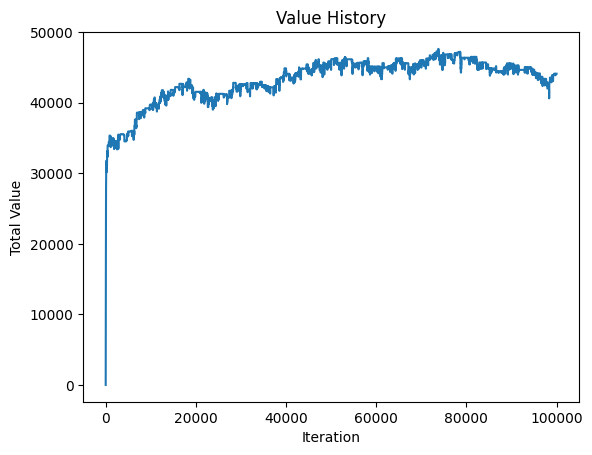

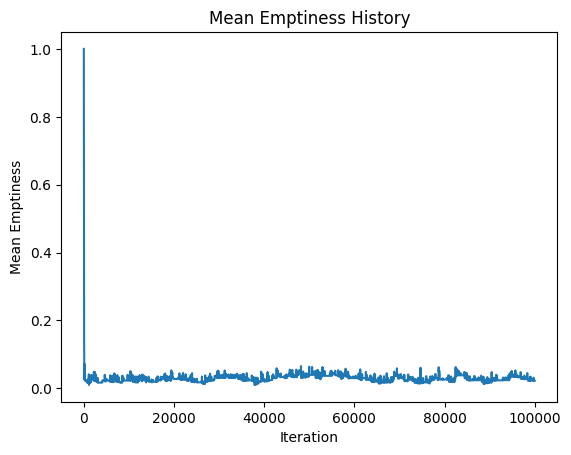

Best mean emptiness: 0.018985107747587916
Final mean emptiness: 0.02255639200150933


In [49]:
import matplotlib.pyplot as plt

theorical_max = np.sum(VALUES)
print("Theorical max:", theorical_max)


values = [v[0] for v in value_history]
plt.plot(range(len(value_history)), values)
plt.xlabel("Iteration")
plt.ylabel("Total Value")
plt.title("Value History")
plt.show()

mean_emptiness = [np.mean(v[2]) for v in value_history]
plt.figure()
plt.plot(range(len(value_history)), mean_emptiness)
plt.xlabel("Iteration")
plt.ylabel("Mean Emptiness")
plt.title("Mean Emptiness History")
plt.show()

best_mean_emptiness = np.mean(best_value[2])
print("Best mean emptiness:", best_mean_emptiness)
final_mean_emptiness = np.mean(value[2])
print("Final mean emptiness:", final_mean_emptiness)

## Conclusion
The new mapping is more compact and easier to manage. The mutation and crossover operations are simplified, leading to potentially better performance in finding optimal solutions. Further testing and tuning of the genetic algorithm parameters may yield even better results.

As we are checking a lot of parameters, this solution is slower than the previous one, but is more effective. 

with 50000 iterations

PB 1: solution 1065, theoretical maximum 1065, time 10.7s

PB 2: solution 48024, theoretical maximum 52620, time 15.0s

PB 3: solution 1320226, theoretical maximum 2490698, time 3m 5.0s

In [63]:
for i in range(NUM_KNAPSACKS):
    (idx,) = np.where(initial_solution == (i))
    print(WEIGHTS[idx].sum(axis=0) / CONSTRAINTS[i])

[0.95065959 0.75634341 0.2404021  0.92698908 0.90044944 0.99825936
 0.9048583  0.31006914 0.43548556 0.90835808]
[0.50198413 0.95235629 0.61864407 0.97647601 0.83319269 0.66053032
 0.36210357 0.34329697 0.45947335 0.59165826]
[0.93368072 0.9869012  0.94192771 0.81792859 0.59662999 0.67329675
 0.55910326 0.3028169  0.70522562 0.74711525]
[0.93071945 0.81782367 0.88821065 0.58447489 0.99696093 0.99391234
 0.8721631  0.7743309  0.41879482 0.94110196]
[0.6889159  0.95623539 0.66342186 0.67664192 0.98924269 0.98634812
 0.74608    0.61688551 0.81072807 0.4717559 ]
[0.64058088 0.71563432 0.54058024 0.19545063 0.66974544 0.82571685
 0.85950692 0.19052488 0.50482949 0.72777307]
[0.58307069 0.63572621 0.48366162 0.61830107 0.58467808 0.96407186
 0.99862069 0.4691596  0.3130696  0.43928036]
[0.45214052 0.31961397 0.56176929 0.82105263 0.92649903 0.77707006
 0.31229309 0.62627407 0.36631476 0.95632393]
[0.4465977  0.61291008 0.51660909 0.99212175 0.91271913 0.57309417
 0.76648614 0.62663916 0.9456